In [2]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

import scipy.stats
from scipy.stats import norm
from scipy.stats import uniform
from astroML import stats as astroMLstats
from tqdm.notebook import tqdm
plt.rcParams['figure.figsize'] = [6, 6]

import astropy
astropy.cosmology.Planck18

FlatLambdaCDM(name='Planck18', H0=<Quantity 67.66 km / (Mpc s)>, Om0=0.30966, Tcmb0=<Quantity 2.7255 K>, Neff=3.046, m_nu=<Quantity [0.  , 0.  , 0.06] eV>, Ob0=0.04897)

In [5]:
from urllib.request import urlretrieve
urlretrieve("http://das.sdss.org/va/qsocat/dr7qso.dat", './dr7qso.dat')
z = np.loadtxt('dr7qso.dat', skiprows = 80, usecols=3)
print("data recovered")

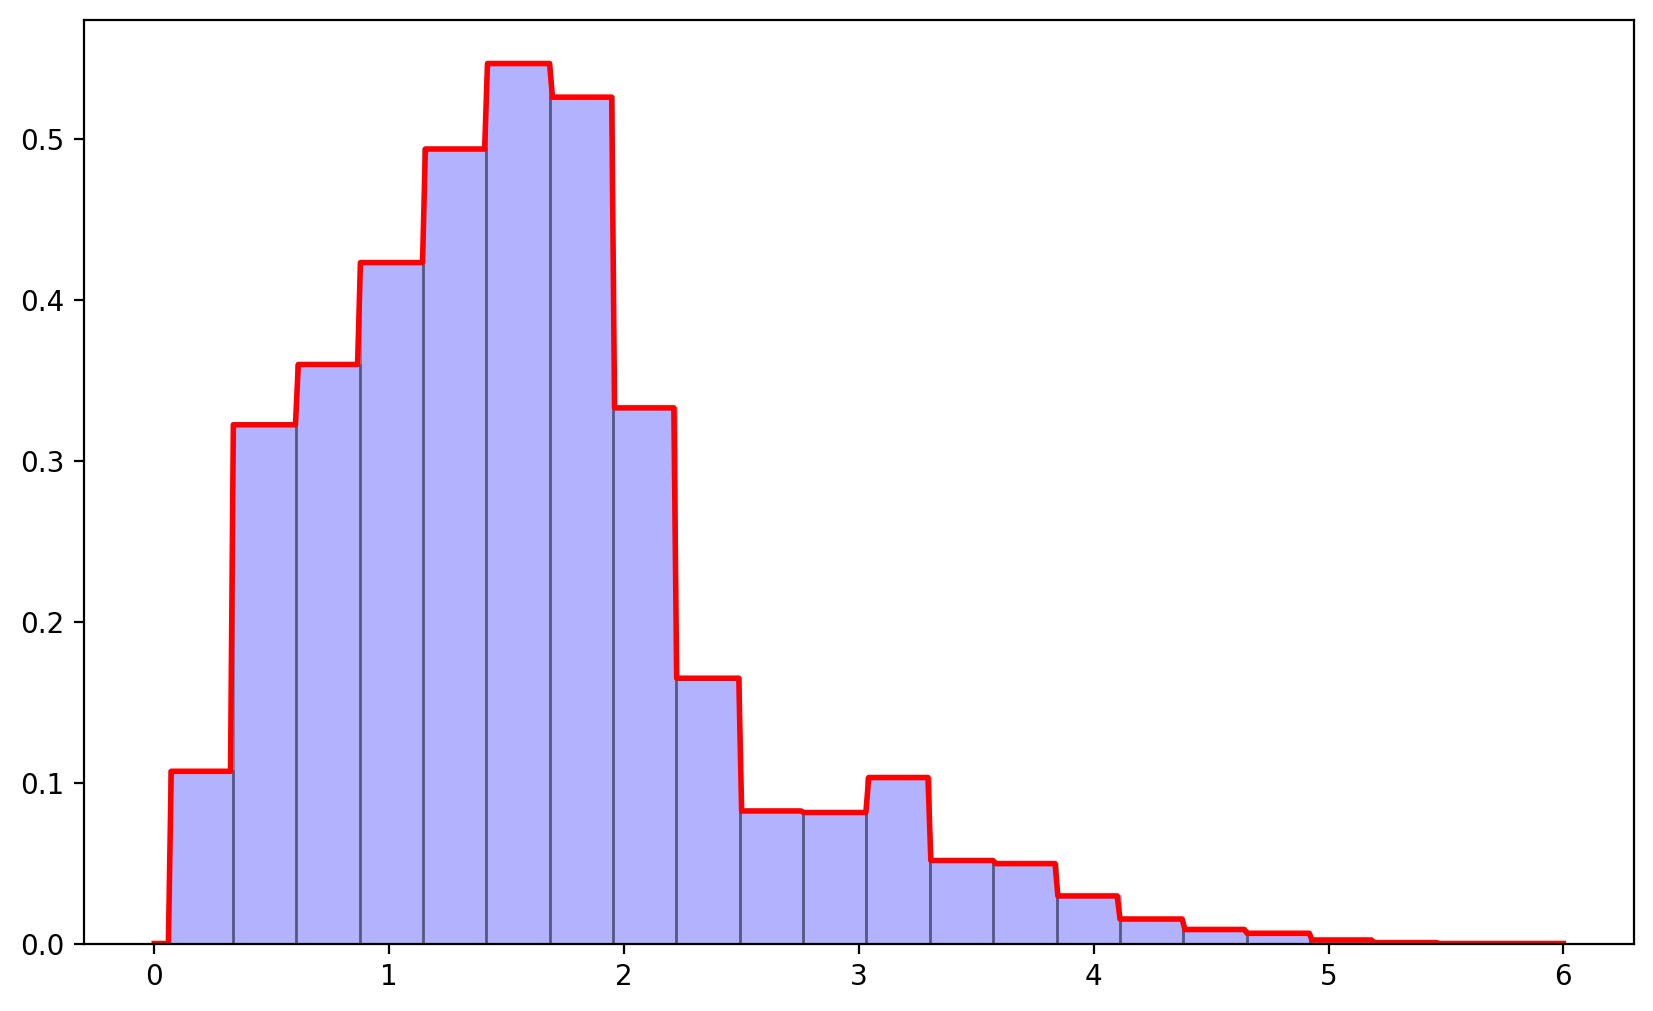

In [40]:
n_bins = 20
counts, bin_edges = np.histogram(z, bins = n_bins, density = True) #density permette di normalizzarlo
max_hist = np.max(counts)

def pdf(x):
    if x < bin_edges[0] or x > bin_edges[-1]:
        return 0.0
    for i in range(len(counts)):
        if bin_edges[i] <= x <= bin_edges[i+1]:
            return counts[i]
    return 0.0

x_range = np.linspace(0, 6, 500)
y_range = [pdf(val) for val in x_range]
plt.figure(figsize=(10, 6))

plt.hist(z, bins=n_bins, density=True, ec='black', alpha=0.3, color='blue', label='Dati originali')

plt.plot(x_range, y_range, color='red', lw=2, label='PDF calcolata')

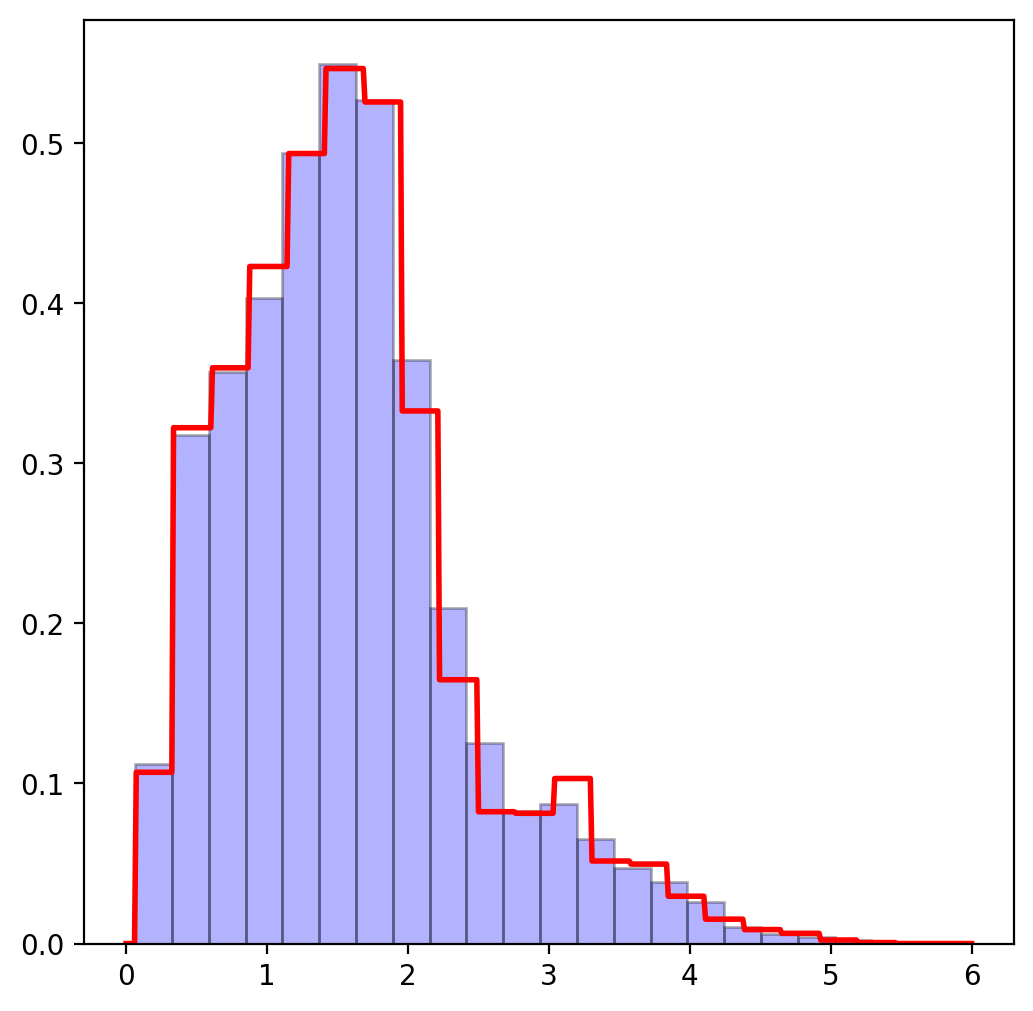

In [39]:
#rejection sampling
def rejection_sampling(N_sampled):
    sampled_datas = []
    x_min, x_max = bin_edges[0], bin_edges[-1]

    while(len(sampled_datas) < N_sampled):
        x_trial = np.random.uniform(x_min, x_max)
        y_trial = np.random.uniform(0, max_hist)

        if(y_trial <= pdf(x_trial)):
            sampled_datas.append(x_trial)

    return sampled_datas
N_sampled = 10000
sampled_rejected = rejection_sampling(N_sampled)
plt.hist(sampled_rejected, bins=n_bins, density=True, ec='black', alpha=0.3, color='blue', label='Dati RNG con Rejection Sampling')

plt.plot(x_range, y_range, color='red', lw=2, label='PDF calcolata')

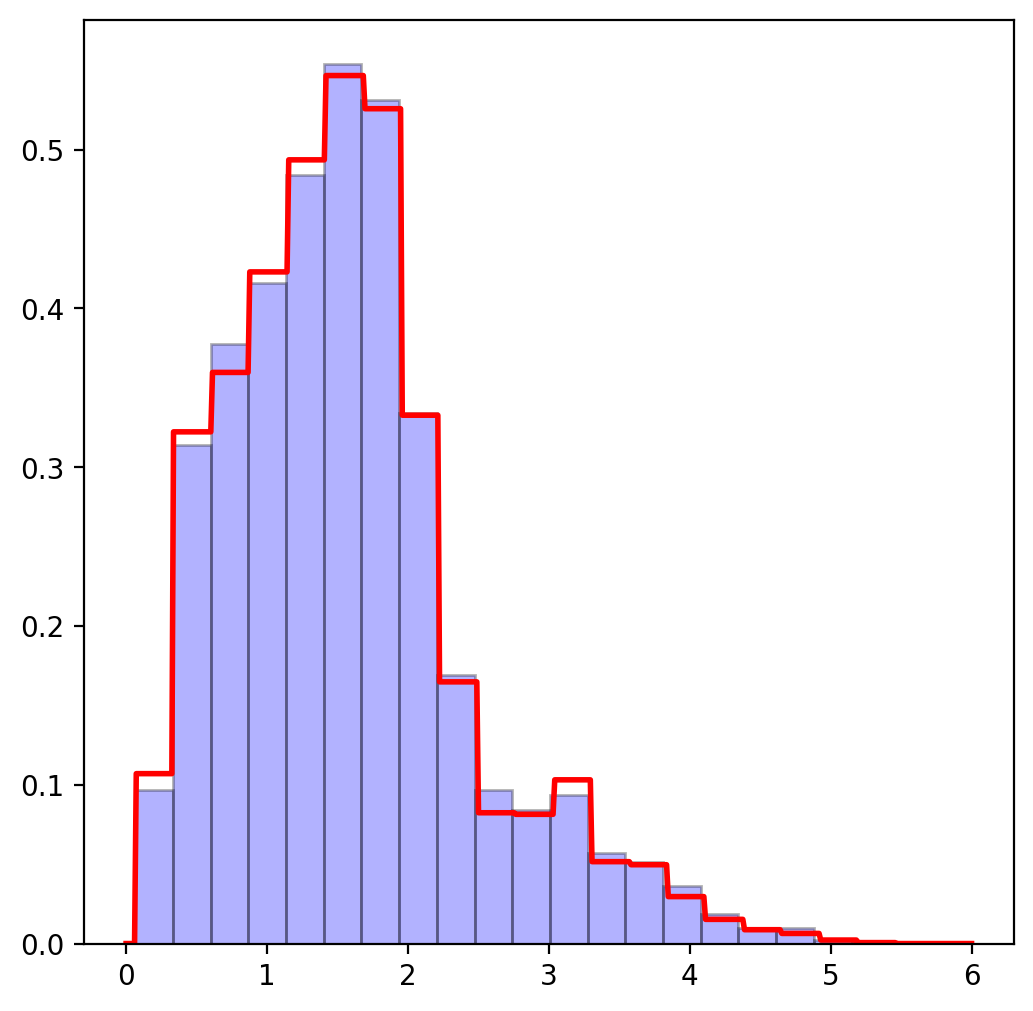

In [48]:
#inverse sampling
dx = bin_edges[1] - bin_edges[0]
cdf= np.cumsum(dx * counts)

cdf=np.insert(cdf, 0, 0)

def inverse_sampling(N_sampled):
    sampled_datas = []
    u = np.random.uniform(0,1, N_sampled)

    #invertiamo tramite una interpolazione lineare tra i bordi dei bin e i cdf, così da trovare x t.c. CDF(x) = u
    sampled_datas = np.interp(u, cdf, bin_edges)

    return sampled_datas

sampled_inverse = inverse_sampling(N_sampled)

plt.hist(sampled_inverse, bins=n_bins, density=True, ec='black', alpha=0.3, color='blue', label='Dati RNG con Rejection Sampling')

plt.plot(x_range, y_range, color='red', lw=2, label='PDF calcolata')